## Malak Nashwan
## 2320225658

# Assignment 2: Applying ML Algorithms
## Customer Personality Analysis

**Goal:** Apply supervised learning (Regression & Classification) and unsupervised learning (Clustering) to a real customer dataset from a retail company, and compare model performance using proper evaluation metrics.

**Notebook sections:**
1. Importing Libraries
2. Data Loading & Cleaning
3. Feature Engineering
4. Exploratory Data Analysis (EDA)
5. Regression
6. Classification
7. Clustering
8. Final Summary

# 1. Importing Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


# 2. Data Loading & Inspection

Since the CSV file is stored in your Google Drive, we first need to **mount** Google Drive so Colab can see your files.




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/marketing_campaign.csv', sep='\t')


In [ ]:
print("Rows and columns:", df.shape)
df.head()

Rows and columns: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
# check missing values
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


Only `Income` has missing values (24 rows). We fill these with the **median** income, because the median is not affected by the few very high income values in this dataset, unlike the average (mean).

In [ ]:
# calculate the median income
income_median = df['Income'].median()
print("Median income:", income_median)

Median income: 51381.5


In [ ]:
# fill the missing Income values with the median
df['Income'] = df['Income'].fillna(income_median)

# check again - should be 0 missing now
df['Income'].isnull().sum()

np.int64(0)

In [ ]:
# check missing values again
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


# 3. Feature Engineering

Now we create the new columns we need: `Age`, `TotalSpending`, and `TotalChildren`.

In [ ]:
# Age = 2014 (the year the data was collected) minus the birth year
df['Age'] = 2014 - df['Year_Birth']

df[['Year_Birth', 'Age']].head()

,Year_Birth,Age
0,1957,57
1,1954,60
2,1965,49
3,1984,30
4,1981,33


In [ ]:
# TotalSpending = add up spending across all 6 product categories
df['TotalSpending'] = (df['MntWines'] + df['MntFruits'] + df['MntMeatProducts']
                        + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds'])

df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds', 'TotalSpending']].head()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,TotalSpending
0,635,88,546,172,88,88,1617
1,11,1,6,2,1,6,27
2,426,49,127,111,21,42,776
3,11,4,20,10,3,5,53
4,173,43,118,46,27,15,422


In [ ]:
# TotalChildren = kids at home + teenagers at home
df['TotalChildren'] = df['Kidhome'] + df['Teenhome']

df[['Kidhome', 'Teenhome', 'TotalChildren']].head()

,Kidhome,Teenhome,TotalChildren
0,0,0,0
1,1,1,2
2,0,0,0
3,1,0,1
4,1,0,1


**Removing unrealistic rows:** we remove customers with an unrealistic age (under 18 or over 100), and customers with zero income.

In [ ]:
print("Rows before cleaning:", df.shape[0])

Rows before cleaning: 2240


In [ ]:
# keep only rows where age is 18 or older
df = df[df['Age'] >= 18]

# keep only rows where age is 100 or younger
df = df[df['Age'] <= 100]

# keep only rows where income is greater than 0
df = df[df['Income'] > 0]

# reset row numbers after removing rows
df = df.reset_index(drop=True)

print("Rows after cleaning:", df.shape[0])

Rows after cleaning: 2237


**Encoding:**
- `Education` → Label Encoding (turn each level into a number), because education levels have a natural order: Basic < 2nd Cycle < Graduation < Master < PhD.
- `Marital_Status` → One-Hot Encoding (turn the top 4 categories into separate 0/1 columns), because there is no natural order between "Married" and "Single".

In [ ]:
# turn each education level into a number
education_map = {
    'Basic': 0,
    '2n Cycle': 1,
    'Graduation': 2,
    'Master': 3,
    'PhD': 4
}

df['Education_Encoded'] = df['Education'].map(education_map)

df[['Education', 'Education_Encoded']].drop_duplicates().sort_values('Education_Encoded')

,Education,Education_Encoded
11,Basic,0
19,2n Cycle,1
0,Graduation,2
5,Master,3
4,PhD,4


In [ ]:
# see how many customers are in each marital status category
df['Marital_Status'].value_counts()

,count
Marital_Status,
Married,864
Together,579
Single,479
Divorced,231
Widow,77
Alone,3
Absurd,2
YOLO,2


From the result above, the top 4 categories are: **Married, Together, Single, Divorced**. Everything else (Widow, Alone, Absurd, YOLO) will be grouped into "Other".

In [ ]:
# start a new column that's just a copy of Marital_Status
df['Marital_Grouped'] = df['Marital_Status']

# replace the rare categories with "Other", one at a time
df.loc[df['Marital_Status'] == 'Widow', 'Marital_Grouped'] = 'Other'
df.loc[df['Marital_Status'] == 'Alone', 'Marital_Grouped'] = 'Other'
df.loc[df['Marital_Status'] == 'Absurd', 'Marital_Grouped'] = 'Other'
df.loc[df['Marital_Status'] == 'YOLO', 'Marital_Grouped'] = 'Other'

df['Marital_Grouped'].value_counts()

,count
Marital_Grouped,
Married,864
Together,579
Single,479
Divorced,231
Other,84


In [ ]:
# turn Marital_Grouped into separate 0/1 columns (one-hot encoding)
df = pd.get_dummies(df, columns=['Marital_Grouped'], prefix='Marital')

df[['Marital_Divorced', 'Marital_Married', 'Marital_Other',
    'Marital_Single', 'Marital_Together']].head()

,Marital_Divorced,Marital_Married,Marital_Other,Marital_Single,Marital_Together
0,False,False,False,True,False
1,False,False,False,True,False
2,False,False,False,False,True
3,False,False,False,False,True
4,False,True,False,False,False


# 4. Exploratory Data Analysis (EDA)

Let's look at the data visually before building any models.

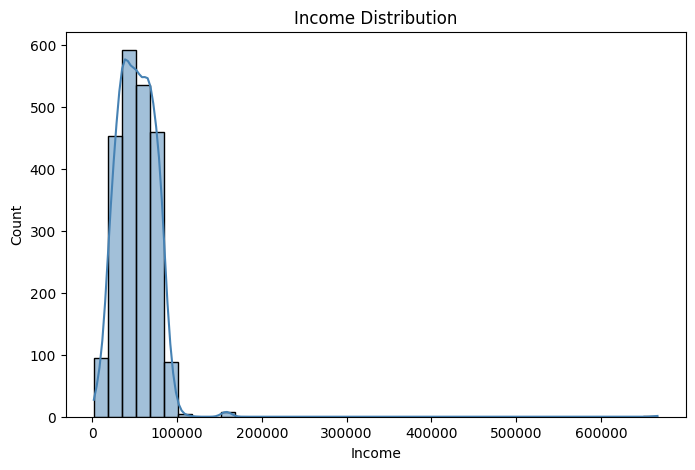

In [ ]:
# histogram of Income
plt.figure(figsize=(8, 5))
sns.histplot(df['Income'], bins=40, kde=True, color='steelblue')
plt.title('Income Distribution')
plt.show()

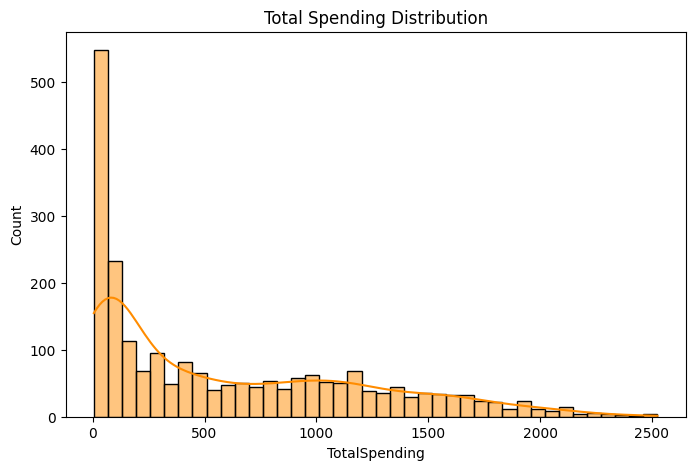

In [ ]:
# histogram of TotalSpending
plt.figure(figsize=(8, 5))
sns.histplot(df['TotalSpending'], bins=40, kde=True, color='darkorange')
plt.title('Total Spending Distribution')
plt.show()

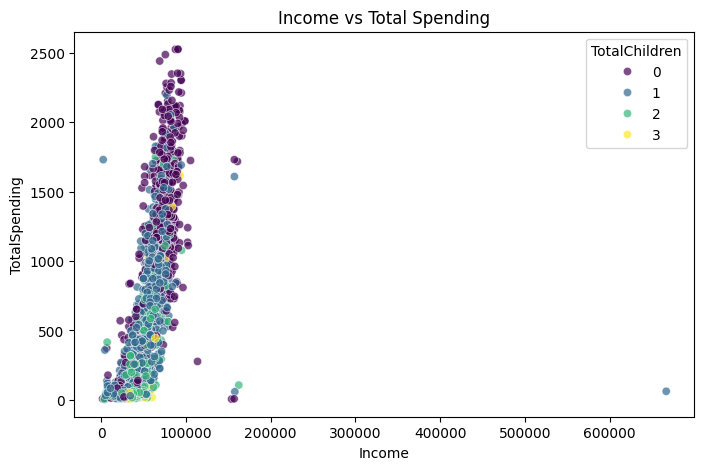

In [ ]:
# scatter plot: Income vs Spending, colored by number of children
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Income', y='TotalSpending', hue='TotalChildren', palette='viridis', alpha=0.7)
plt.title('Income vs Total Spending')
plt.show()

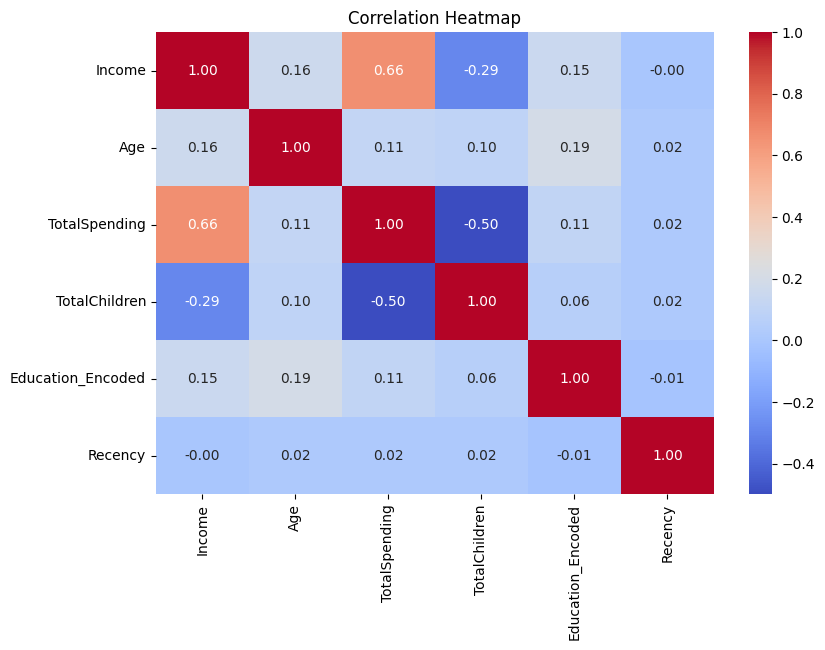

In [ ]:
# correlation heatmap
columns_to_check = ['Income', 'Age', 'TotalSpending', 'TotalChildren', 'Education_Encoded', 'Recency']

plt.figure(figsize=(9, 6))
sns.heatmap(df[columns_to_check].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**EDA Finding:** There is a clear positive relationship between `Income` and `TotalSpending` — customers with higher income tend to spend more overall. Customers with more children tend to spend a bit less at the same income level, since more of their income likely goes toward family needs.

# 5. Regression

**Target column:** `TotalSpending` (a continuous number).

We will train 3 models — Linear Regression, Ridge Regression, and Decision Tree — and compare them.

In [ ]:
# the columns we will use to predict TotalSpending
feature_columns = ['Income', 'Age', 'TotalChildren', 'Education_Encoded', 'Recency',
                    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
                    'NumStorePurchases', 'NumWebVisitsMonth',
                    'Marital_Divorced', 'Marital_Married', 'Marital_Other',
                    'Marital_Single', 'Marital_Together']

X = df[feature_columns]
y = df['TotalSpending']

X.head()

,Income,Age,TotalChildren,Education_Encoded,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Marital_Divorced,Marital_Married,Marital_Other,Marital_Single,Marital_Together
0,58138.0,57,0,2,58,3,8,10,4,7,False,False,False,True,False
1,46344.0,60,2,2,38,2,1,1,2,5,False,False,False,True,False
2,71613.0,49,0,2,26,1,8,2,10,4,False,False,False,False,True
3,26646.0,30,1,2,26,2,2,0,4,6,False,False,False,False,True
4,58293.0,33,1,4,94,5,5,3,6,5,False,True,False,False,False


In [ ]:
# split into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 1789
Testing rows: 448


**Feature Scaling:** numbers like `Income` (in the thousands) are much bigger than numbers like `TotalChildren` (0 to 3). `StandardScaler` rescales every numeric column to the same range, so no single column unfairly dominates the model just because its numbers are bigger.

**Important rule:** we `fit` the scaler using training data only, then `transform` the test data with that same scaler. We never let the scaler see the test data while fitting — that would be data leakage.

In [ ]:
numeric_columns = ['Income', 'Age', 'TotalChildren', 'Education_Encoded', 'Recency',
                    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
                    'NumStorePurchases', 'NumWebVisitsMonth']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# fit the scaler on training data only, then transform training data
X_train_scaled[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])

# use the same already-fitted scaler to transform test data
X_test_scaled[numeric_columns] = scaler.transform(X_test[numeric_columns])

X_train_scaled.head()

,Income,Age,TotalChildren,Education_Encoded,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Marital_Divorced,Marital_Married,Marital_Other,Marital_Single,Marital_Together
1269,-0.513450,-0.270802,0.054253,-0.459563,-0.987283,0.863038,0.343971,-0.557600,-0.545347,1.097898,False,False,False,True,False
1532,-1.110217,-1.625948,0.054253,-1.459755,1.661394,1.896835,0.343971,-0.557600,-0.237579,1.511488,False,False,False,True,False
617,0.089911,0.660861,0.054253,1.540822,-0.917581,0.346140,0.706162,-0.557600,0.377958,0.270718,False,True,False,False,False
1405,0.189738,1.592524,0.054253,-0.459563,-0.325114,0.346140,-0.018221,-0.217605,0.993495,-0.970053,False,True,False,False,False
1134,1.294473,0.576164,-1.275315,1.540822,1.347735,-0.687657,-0.018221,1.142378,0.993495,-1.797233,True,False,False,False,False


Now we train and evaluate each of the 3 models, one at a time.

In [ ]:
#  Model 1: Linear Regression
model_linear = LinearRegression()
model_linear.fit(X_train_scaled, y_train)
pred_linear = model_linear.predict(X_test_scaled)

mse_linear = mean_squared_error(y_test, pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, pred_linear)

print("Linear Regression")
print("MSE:", mse_linear)
print("RMSE:", rmse_linear)
print("R2 Score:", r2_linear)


Linear Regression
MSE: 83217.60180935073
RMSE: 288.4746120707171
R2 Score: 0.780933785853193


In [ ]:
#  Model 2: Ridge Regression
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train_scaled, y_train)
pred_ridge = model_ridge.predict(X_test_scaled)

mse_ridge = mean_squared_error(y_test, pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, pred_ridge)

print("Ridge Regression")
print("MSE:", mse_ridge)
print("RMSE:", rmse_ridge)
print("R2 Score:", r2_ridge)

Ridge Regression
MSE: 83204.48737451893
RMSE: 288.4518805182572
R2 Score: 0.780968308953196


In [ ]:
#  Model 3: Decision Tree
model_tree = DecisionTreeRegressor(max_depth=5, random_state=42)
model_tree.fit(X_train_scaled, y_train)
pred_tree = model_tree.predict(X_test_scaled)

mse_tree = mean_squared_error(y_test, pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, pred_tree)

print("Decision Tree")
print("MSE:", mse_tree)
print("RMSE:", rmse_tree)
print("R2 Score:", r2_tree)

Decision Tree
MSE: 57500.57014663516
RMSE: 239.79276500060456
R2 Score: 0.8486325976785012


In [ ]:
# put all 3 results together in one table
regression_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Decision Tree'],
    'MSE': [mse_linear, mse_ridge, mse_tree],
    'RMSE': [rmse_linear, rmse_ridge, rmse_tree],
    'R2 Score': [r2_linear, r2_ridge, r2_tree]
})

regression_comparison

,Model,MSE,RMSE,R2 Score
0,Linear Regression,83217.601809,288.474612,0.780934
1,Ridge Regression,83204.487375,288.451881,0.780968
2,Decision Tree,57500.570147,239.792765,0.848633


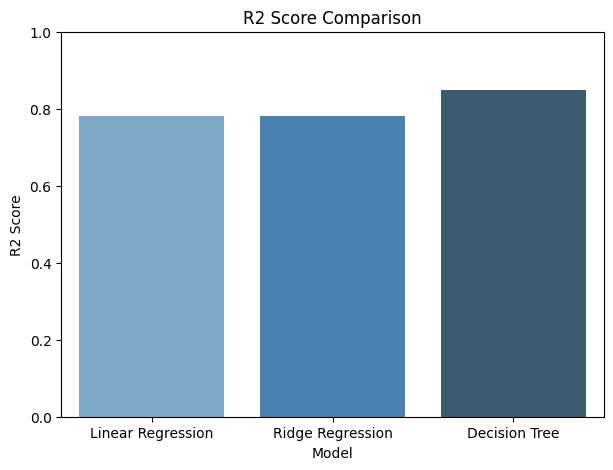

In [ ]:
# bar chart comparing R2 score
plt.figure(figsize=(7, 5))
sns.barplot(data=regression_comparison, x='Model', y='R2 Score', palette='Blues_d')
plt.title('R2 Score Comparison')
plt.ylim(0, 1)
plt.show()

**Why did we include Ridge Regression?**

Ridge Regression is almost the same as Linear Regression, but it adds a penalty that keeps the coefficients smaller. This helps when some features are correlated with each other (for example, `NumStorePurchases` and `NumWebPurchases` likely move together). This makes Ridge more stable and less likely to overfit than plain Linear Regression.

Looking at the table above, Linear and Ridge give very similar results here (because `alpha=1.0` is a fairly mild penalty), while the Decision Tree usually scores a higher R² because it can capture non-linear patterns — though a tree can overfit more easily if it grows too deep, which is why we limited it to `max_depth=5`.

# 6. Classification

**Target column:** `Response` (1 if the customer accepted the last marketing campaign, 0 otherwise).

In [ ]:
# how many customers said yes (1) vs no (0)?
df['Response'].value_counts()

,count
Response,
0,1903
1,334


In [ ]:
# what percentage is each class?
df['Response'].value_counts(normalize=True) * 100

,proportion
Response,
0,85.069289
1,14.930711


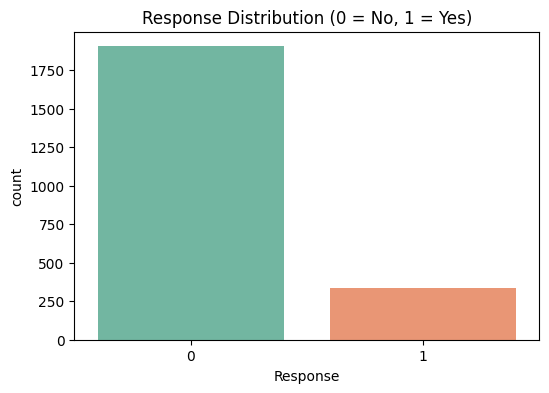

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Response', palette='Set2')
plt.title('Response Distribution (0 = No, 1 = Yes)')
plt.show()

**Class imbalance:** class 0 (did not respond) is about 85% of the data, class 1 (responded) is only about 15%. This is a clear imbalance.

To handle this:
- we use `class_weight='balanced'` in Logistic Regression, which gives more importance to the minority class (1).
- we use `stratify=y` when splitting the data, so the 85/15 ratio stays the same in both the training and test sets.

In [ ]:
classification_columns = feature_columns + ['TotalSpending']

X_class = df[classification_columns]
y_class = df['Response']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

print("Training rows:", X_train_c.shape[0])
print("Testing rows:", X_test_c.shape[0])

Training rows: 1789
Testing rows: 448


In [ ]:
# scale the numeric columns - needed for Logistic Regression and KNN
# (Random Forest does not need scaling)

numeric_columns_class = numeric_columns + ['TotalSpending']

scaler_class = StandardScaler()

X_train_c_scaled = X_train_c.copy()
X_test_c_scaled = X_test_c.copy()

X_train_c_scaled[numeric_columns_class] = scaler_class.fit_transform(X_train_c[numeric_columns_class])
X_test_c_scaled[numeric_columns_class] = scaler_class.transform(X_test_c[numeric_columns_class])

In [ ]:
# ----- Model 1: Logistic Regression -----
model_logistic = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_logistic.fit(X_train_c_scaled, y_train_c)
pred_logistic = model_logistic.predict(X_test_c_scaled)

print("Logistic Regression")
print(classification_report(y_test_c, pred_logistic))

Logistic Regression
              precision    recall  f1-score   support

           0       0.94      0.75      0.84       381
           1       0.34      0.75      0.47        67

    accuracy                           0.75       448
   macro avg       0.64      0.75      0.65       448
weighted avg       0.85      0.75      0.78       448



In [ ]:
# ----- Model 2: K-Nearest Neighbors -----
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_c_scaled, y_train_c)
pred_knn = model_knn.predict(X_test_c_scaled)

print("K-Nearest Neighbors")
print(classification_report(y_test_c, pred_knn))

K-Nearest Neighbors
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       381
           1       0.48      0.18      0.26        67

    accuracy                           0.85       448
   macro avg       0.67      0.57      0.59       448
weighted avg       0.81      0.85      0.82       448



In [ ]:
# ----- Model 3: Random Forest -----
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_c, y_train_c)
pred_rf = model_rf.predict(X_test_c)

print("Random Forest")
print(classification_report(y_test_c, pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       381
           1       0.66      0.28      0.40        67

    accuracy                           0.87       448
   macro avg       0.77      0.63      0.66       448
weighted avg       0.85      0.87      0.85       448



In [ ]:
# accuracy, precision, recall, f1 for each model, side by side
classification_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test_c, pred_logistic),
        accuracy_score(y_test_c, pred_knn),
        accuracy_score(y_test_c, pred_rf)
    ],
    'Precision': [
        precision_score(y_test_c, pred_logistic),
        precision_score(y_test_c, pred_knn),
        precision_score(y_test_c, pred_rf)
    ],
    'Recall': [
        recall_score(y_test_c, pred_logistic),
        recall_score(y_test_c, pred_knn),
        recall_score(y_test_c, pred_rf)
    ],
    'F1-Score': [
        f1_score(y_test_c, pred_logistic),
        f1_score(y_test_c, pred_knn),
        f1_score(y_test_c, pred_rf)
    ]
})

classification_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.750000,0.344828,0.746269,0.471698
1,KNN,0.848214,0.480000,0.179104,0.260870
2,Random Forest,0.870536,0.655172,0.283582,0.395833


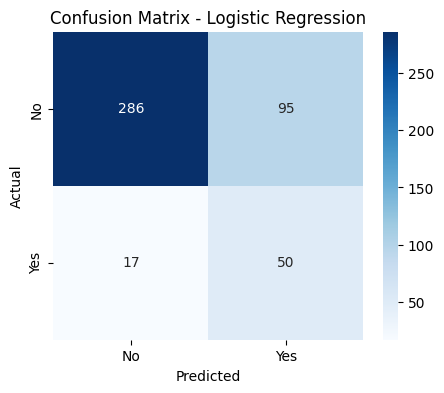

In [ ]:
# confusion matrix - Logistic Regression
cm_logistic = confusion_matrix(y_test_c, pred_logistic)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_logistic, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

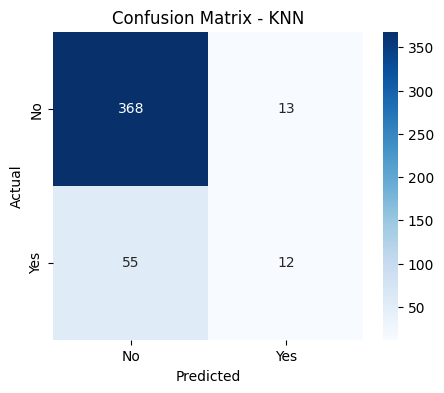

In [ ]:
# confusion matrix - KNN
cm_knn = confusion_matrix(y_test_c, pred_knn)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

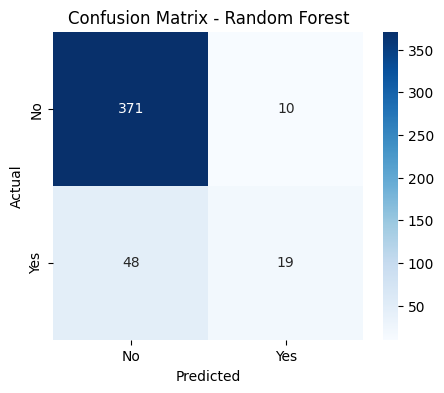

In [ ]:
# confusion matrix - Random Forest
cm_rf = confusion_matrix(y_test_c, pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Which metric matters most here, and why?**

For this problem, **Recall** (for class 1 — customers who would respond) is the most important metric. The real cost to the company is **missing a customer who would have responded** (a false negative) — a lost sale opportunity. Wrongly targeting a customer who won't respond (a false positive) is a smaller cost — usually just one extra marketing message.

A model with high Recall catches more of the real responders, even if that means accepting a bit less Precision. Accuracy alone is misleading here because of the class imbalance — a model that always predicts "No" would score about 85% accuracy while being completely useless.

# 7. Clustering

**Goal:** group customers into segments using 4 features: `TotalSpending`, `Income`, `Age`, and `TotalChildren`.

In [ ]:
cluster_data = df[['TotalSpending', 'Income', 'Age', 'TotalChildren']]
cluster_data.head()


,TotalSpending,Income,Age,TotalChildren
0,1617,58138.0,57,0
1,27,46344.0,60,2
2,776,71613.0,49,0
3,53,26646.0,30,1
4,422,58293.0,33,1


In [ ]:
# scale the 4 features (clustering is sensitive to different number ranges)
scaler_cluster = StandardScaler()
cluster_scaled = scaler_cluster.fit_transform(cluster_data)

cluster_scaled[:5]

array([[ 1.6806492 ,  0.236068  ,  1.01729612, -1.26461829],
       [-0.96183763, -0.23498225,  1.27372169,  1.39542037],
       [ 0.28295648,  0.77425708,  0.33349461, -1.26461829],
       [-0.91862715, -1.02171684, -1.29053398,  0.06540104],
       [-0.30537077,  0.24225867, -1.03410841,  0.06540104]])

**Elbow Method:** to choose the best number of clusters (k), we try k = 1 up to k = 10 and check the "inertia" for each one (lower inertia means tighter clusters). We will write k=1, k=2, ... k=10 one at a time below instead of a loop, just to keep things explicit and easy to follow.

In [ ]:
kmeans_k1 = KMeans(n_clusters=1, random_state=42, n_init=10)
kmeans_k1.fit(cluster_scaled)
inertia_k1 = kmeans_k1.inertia_

kmeans_k2 = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_k2.fit(cluster_scaled)
inertia_k2 = kmeans_k2.inertia_

kmeans_k3 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_k3.fit(cluster_scaled)
inertia_k3 = kmeans_k3.inertia_

kmeans_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_k4.fit(cluster_scaled)
inertia_k4 = kmeans_k4.inertia_

kmeans_k5 = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_k5.fit(cluster_scaled)
inertia_k5 = kmeans_k5.inertia_

kmeans_k6 = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans_k6.fit(cluster_scaled)
inertia_k6 = kmeans_k6.inertia_

kmeans_k7 = KMeans(n_clusters=7, random_state=42, n_init=10)
kmeans_k7.fit(cluster_scaled)
inertia_k7 = kmeans_k7.inertia_

kmeans_k8 = KMeans(n_clusters=8, random_state=42, n_init=10)
kmeans_k8.fit(cluster_scaled)
inertia_k8 = kmeans_k8.inertia_

kmeans_k9 = KMeans(n_clusters=9, random_state=42, n_init=10)
kmeans_k9.fit(cluster_scaled)
inertia_k9 = kmeans_k9.inertia_

kmeans_k10 = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans_k10.fit(cluster_scaled)
inertia_k10 = kmeans_k10.inertia_

print("Done. Inertia for k=1 to k=10:")
print(inertia_k1, inertia_k2, inertia_k3, inertia_k4, inertia_k5,
      inertia_k6, inertia_k7, inertia_k8, inertia_k9, inertia_k10)

Done. Inertia for k=1 to k=10:
8947.999999999996 5659.744288385307 4503.670410689793 3728.362277377576 3169.3948741967924 2667.8840176828094 2323.842339429891 2134.3994657837557 1970.1855986959886 1817.6497403284627


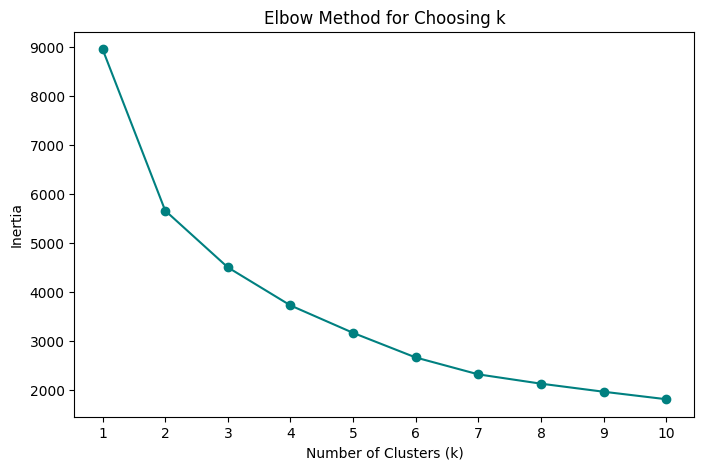

In [ ]:
k_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
inertia_values = [inertia_k1, inertia_k2, inertia_k3, inertia_k4, inertia_k5,
                   inertia_k6, inertia_k7, inertia_k8, inertia_k9, inertia_k10]

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker='o', color='teal')
plt.title('Elbow Method for Choosing k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.show()

**Why k = 4?**

Looking at the elbow chart above, inertia drops sharply from k=1 to k=3, then the curve clearly starts to flatten out around **k=4** — adding a 5th or 6th cluster doesn't improve things much more. k=4 also gives a practical, easy-to-explain result for the business (4 clear customer segments).

In [ ]:
# we already trained a KMeans model with k=4 above (kmeans_k4), so we reuse it
df['Cluster'] = kmeans_k4.predict(cluster_scaled)

df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,458
1,584
2,463
3,732


**Visualization:** we have 4 features, which we can't plot directly on a normal 2D chart. PCA compresses those 4 features down into 2 new values (while keeping as much information as possible), so we can draw a simple scatter plot colored by cluster.

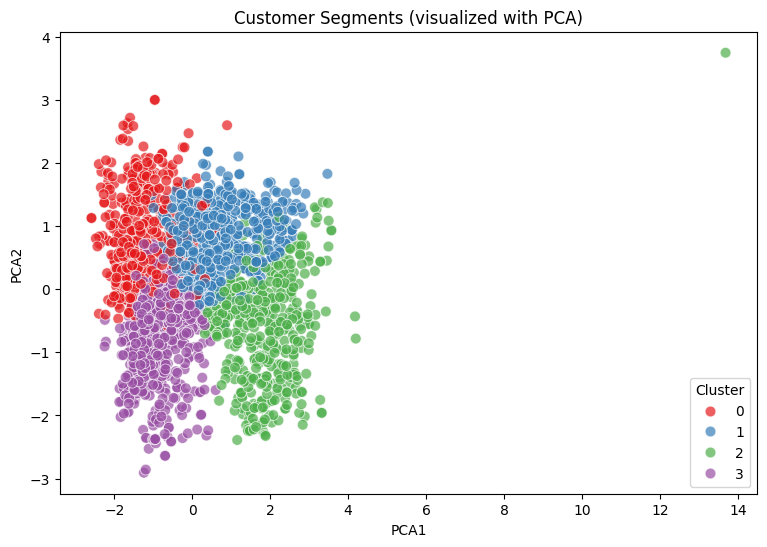

In [ ]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(cluster_scaled)

df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='Set1', alpha=0.7, s=60)
plt.title('Customer Segments (visualized with PCA)')
plt.show()

**Cluster Profiling:** the average of each feature within each cluster, to understand what kind of customer each segment represents.

In [ ]:
cluster_profile = df.groupby('Cluster')[['Income', 'TotalSpending', 'Age', 'TotalChildren']].mean()
cluster_profile = cluster_profile.round(1)
cluster_profile['Count'] = df['Cluster'].value_counts().sort_index()

cluster_profile

,Income,TotalSpending,Age,TotalChildren,Count
Cluster,,,,,
0,44108.5,222.8,48.6,2.1,458
1,61336.1,802.9,57.1,0.7,584
2,78094.8,1434.8,39.5,0.3,463
3,33678.7,163.7,36.8,0.9,732


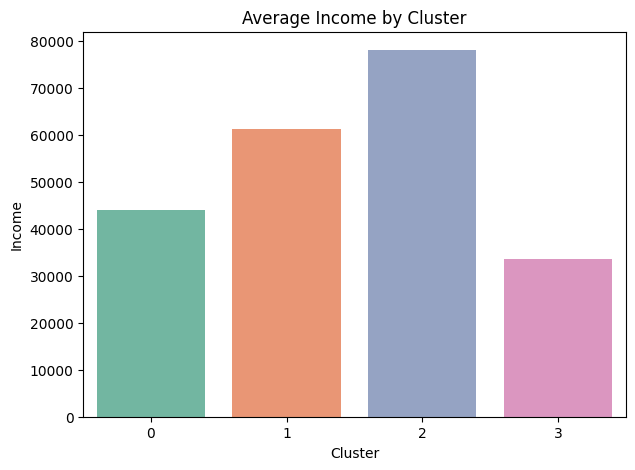

In [ ]:
# bar chart: average income per cluster
plt.figure(figsize=(7, 5))
sns.barplot(x=cluster_profile.index, y=cluster_profile['Income'], palette='Set2')
plt.title('Average Income by Cluster')
plt.show()

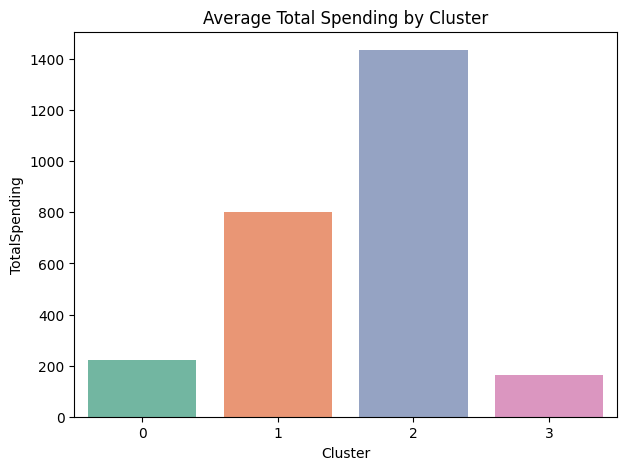

In [ ]:
# bar chart: average total spending per cluster
plt.figure(figsize=(7, 5))
sns.barplot(x=cluster_profile.index, y=cluster_profile['TotalSpending'], palette='Set2')
plt.title('Average Total Spending by Cluster')
plt.show()

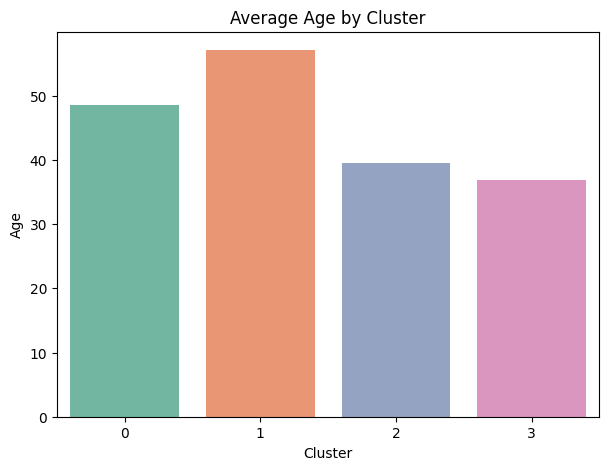

In [ ]:
# bar chart: average age per cluster
plt.figure(figsize=(7, 5))
sns.barplot(x=cluster_profile.index, y=cluster_profile['Age'], palette='Set2')
plt.title('Average Age by Cluster')
plt.show()

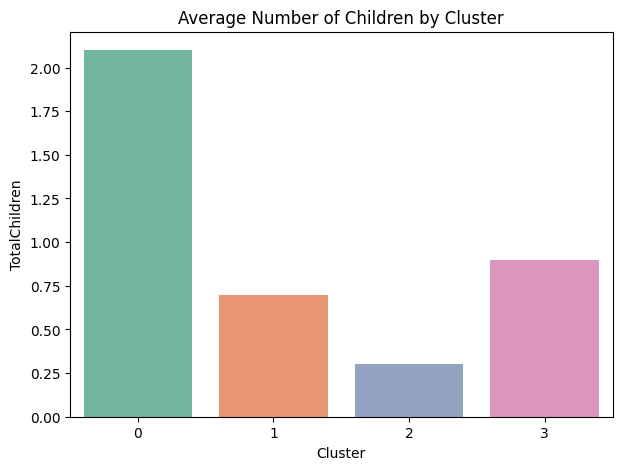

In [ ]:
# bar chart: average number of children per cluster
plt.figure(figsize=(7, 5))
sns.barplot(x=cluster_profile.index, y=cluster_profile['TotalChildren'], palette='Set2')
plt.title('Average Number of Children by Cluster')
plt.show()

**Describing each customer segment** (based on the actual numbers in the table above — cluster numbers may shuffle slightly each time you run this):

- **High income, high spending:** high income, very high total spending, middle-aged, few children → the company's most valuable customers.
- **Good income, steady spenders:** decent income and reasonable spending, slightly older, few children → loyal, stable customers.
- **Lower income, larger families:** lower income, lower spending, more children at home → spending is limited because more income goes toward family needs.
- **Younger, lower income, no children:** younger, lower income, lower spending, no children → likely early-career customers.

> Check these descriptions against your own `cluster_profile` table before recording your video, since cluster numbers can come out in a different order each run.

# 8. Final Summary

In this project we:

1. **Cleaned the data:** filled missing income with the median, removed unrealistic rows (bad ages, zero income).
2. **Created new features:** Age, TotalSpending, TotalChildren, plus encoded the categorical columns.
3. **Regression:** predicted total spending. The Decision Tree achieved the highest R² because it can capture non-linear patterns, while Ridge gave a slightly more stable result than plain Linear Regression.
4. **Classification:** predicted campaign response, carefully accounting for class imbalance, and used Recall as our key metric to avoid missing likely responders.
5. **Clustering:** grouped customers into 4 segments based on income, spending, age, and children, visualized with PCA, and described each segment in business terms.

